In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120})

DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("Durga/Lab/MLDL/data")

pd.set_option("display.max_columns", 120)


import gzip
import struct

def load_mnist_images(path, limit=None):
    with gzip.open(path, "rb") as fh:
        magic, count, rows, cols = struct.unpack(">IIII", fh.read(16))
        if magic != 2051:
            raise ValueError(f"Unexpected image magic number: {magic}")
        if limit is None:
            limit = count
        data = np.frombuffer(fh.read(rows * cols * limit), dtype=np.uint8)
    return data.reshape(limit, rows, cols).astype("float32") / 255.0

def load_mnist_labels(path, limit=None):
    with gzip.open(path, "rb") as fh:
        magic, count = struct.unpack(">II", fh.read(8))
        if magic != 2049:
            raise ValueError(f"Unexpected label magic number: {magic}")
        if limit is None:
            limit = count
        return np.frombuffer(fh.read(limit), dtype=np.uint8)

In [2]:
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

tf.random.set_seed(RANDOM_STATE)

train_images = load_mnist_images(DATA_DIR / "mnist/train-images-idx3-ubyte.gz", limit=8000)
train_labels = load_mnist_labels(DATA_DIR / "mnist/train-labels-idx1-ubyte.gz", limit=8000)
test_images = load_mnist_images(DATA_DIR / "mnist/t10k-images-idx3-ubyte.gz", limit=2000)
test_labels = load_mnist_labels(DATA_DIR / "mnist/t10k-labels-idx1-ubyte.gz", limit=2000)
print("Sequence shape:", train_images.shape)

I0000 00:00:1776648555.873324   37493 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776648555.873644   37493 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776648555.905704   37493 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Sequence shape: (8000, 28, 28)


I0000 00:00:1776648556.578953   37493 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776648556.579209   37493 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ]
)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(
    train_images,
    train_labels,
    validation_split=0.15,
    epochs=3,
    batch_size=128,
    verbose=1,
)

Epoch 1/3


E0000 00:00:1776648557.373201   37493 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected



 1/54 ━━━━━━━━━━━━━━━━━━━━ 41s 790ms/step - accuracy: 0.1094 - loss: 2.3153


 7/54 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1208 - loss: 2.3022   


13/54 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1332 - loss: 2.2933

...


33/54 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7276 - loss: 0.8393


40/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7337 - loss: 0.8248


47/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7388 - loss: 0.8118


53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7426 - loss: 0.8017


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7747 - loss: 0.7179 - val_accuracy: 0.8042 - val_loss: 0.6243


Test accuracy: 0.777


              precision    recall  f1-score   support

           0       0.87      0.91      0.89       175
           1       0.94      0.97      0.95       234
           2       0.91      0.75      0.82       219
           3       0.74      0.80      0.77       207
           4       0.67      0.88      0.76       217
           5       0.64      0.72      0.68       179
           6       0.77      0.78      0.77       178
           7       0.83      0.77      0.80       205
           8       0.78      0.49      0.61       192
           9       0.67      0.66      0.66       194

    accuracy                           0.78      2000
   macro avg       0.78      0.77      0.77      2000
weighted avg       0.78      0.78      0.77      2000



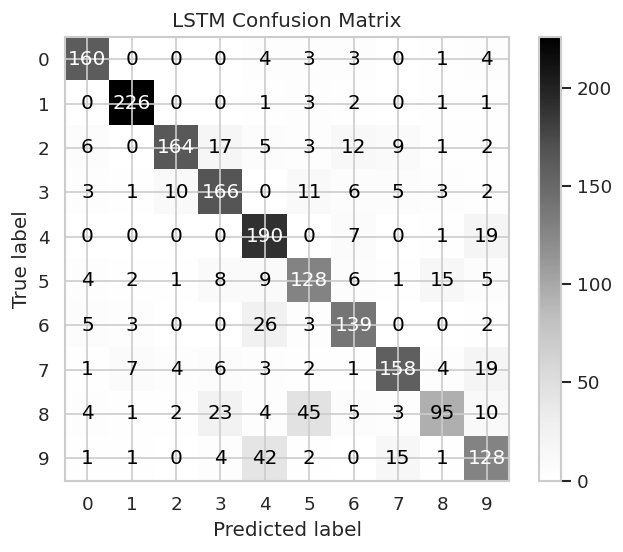

In [4]:
loss, acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy: {acc:.3f}")
pred = model.predict(test_images, verbose=0).argmax(axis=1)
print(classification_report(test_labels, pred))
ConfusionMatrixDisplay.from_predictions(test_labels, pred, cmap="Greys")
plt.title("LSTM Confusion Matrix")
plt.show()